# Load Data

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# File paths
JOBS_PATH = Path("../data/processed/jobs_clean.parquet")
SKILLS_PATH = Path("../data/processed/job_skills.parquet")

# Load data
jobs = pd.read_parquet(JOBS_PATH)
skills = pd.read_parquet(SKILLS_PATH)

print("Jobs shape:", jobs.shape)
print("Skills shape:", skills.shape)

#jobs.head()

Jobs shape: (784895, 18)
Skills shape: (3591106, 2)


# 2. Structure Overview

In [25]:
jobs.info()

<class 'pandas.DataFrame'>
RangeIndex: 784895 entries, 0 to 784894
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        784895 non-null  str           
 1   job_title              784894 non-null  str           
 2   job_location           783850 non-null  str           
 3   job_via                784887 non-null  str           
 4   job_schedule_type      772240 non-null  str           
 5   job_work_from_home     784895 non-null  boolean       
 6   search_location        784895 non-null  str           
 7   job_posted_date        784895 non-null  datetime64[us]
 8   job_no_degree_mention  784895 non-null  boolean       
 9   job_health_insurance   784895 non-null  boolean       
 10  job_country            784846 non-null  str           
 11  salary_rate            33058 non-null   str           
 12  salary_year_avg        21997 non-null   float64       


In [26]:
skills.info()

<class 'pandas.DataFrame'>
RangeIndex: 3591106 entries, 0 to 3591105
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   job_key  str  
 1   skill    str  
dtypes: str(2)
memory usage: 182.9 MB


In [27]:
jobs.columns.tolist(), skills.columns.tolist()

(['job_title_short',
  'job_title',
  'job_location',
  'job_via',
  'job_schedule_type',
  'job_work_from_home',
  'search_location',
  'job_posted_date',
  'job_no_degree_mention',
  'job_health_insurance',
  'job_country',
  'salary_rate',
  'salary_year_avg',
  'salary_hour_avg',
  'company_name',
  'job_skills',
  'job_type_skills',
  'job_key'],
 ['job_key', 'skill'])

In [28]:
jobs[[
    "job_title_short",
    "job_location",
    "job_posted_date",
    "job_work_from_home",
    "salary_year_avg",
    "salary_hour_avg",
    "company_name"
]].describe(include="all")

,job_title_short,job_location,job_posted_date,job_work_from_home,salary_year_avg,salary_hour_avg,company_name
count,784895,783850,784895,784895,21997.000000,10659.000000,784877
unique,10,16998,NaN,2,NaN,NaN,139934
top,Data Analyst,Anywhere,NaN,False,NaN,NaN,Emprego
freq,195874,69506,NaN,715389,NaN,NaN,6458
mean,NaN,NaN,2023-06-25 15:38:39.423775,NaN,123292.217571,47.016321,NaN
min,NaN,NaN,2023-01-01 00:00:04,NaN,15000.000000,8.000000,NaN
25%,NaN,NaN,2023-03-20 09:35:11.500000,NaN,90000.000000,27.500000,NaN
50%,NaN,NaN,2023-06-29 02:26:06,NaN,115000.000000,45.980000,NaN
75%,NaN,NaN,2023-09-27 00:27:37,NaN,150000.000000,61.159996,NaN
max,NaN,NaN,2023-12-31 23:59:58,NaN,960000.000000,391.000000,NaN


# 3. Top Job Roles

In [6]:
top_roles = jobs["job_title_short"].value_counts().reset_index()
top_roles.columns = ["job_title_short", "job_count"]

top_roles.head(15)

,job_title_short,job_count
0,Data Analyst,195874
1,Data Engineer,186009
2,Data Scientist,172118
3,Business Analyst,49015
4,Software Engineer,44834
5,Senior Data Engineer,44523
6,Senior Data Scientist,36937
7,Senior Data Analyst,29193
8,Machine Learning Engineer,14070
9,Cloud Engineer,12322


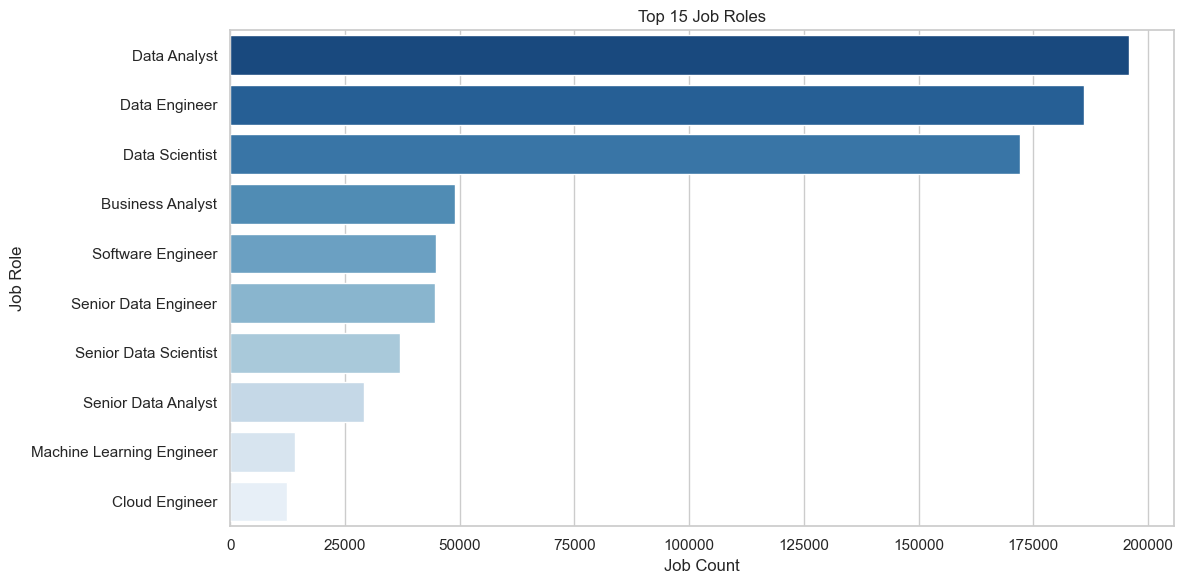

In [88]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_roles.head(15), x="job_count", y="job_title_short", hue ="job_title_short", palette="Blues_r", legend=False)
plt.title("Top 15 Job Roles")
plt.xlabel("Job Count")
plt.ylabel("Job Role")
plt.tight_layout()
plt.savefig("../outputs/charts/top_job_roles.png")
plt.show()

# 4. Top Companies

In [29]:
top_companies = (
    jobs["company_name"]
    .value_counts(dropna=True)
    .reset_index()
)

top_companies.columns = ["company_name", "job_count"]

top_companies.head(15)

,company_name,job_count
0,Emprego,6458
1,Booz Allen Hamilton,2879
2,Dice,2825
3,Harnham,2542
4,Insight Global,2254
5,Citi,2162
6,Confidenziale,2004
7,Listopro,1978
8,Capital One,1945
9,Robert Half,1862


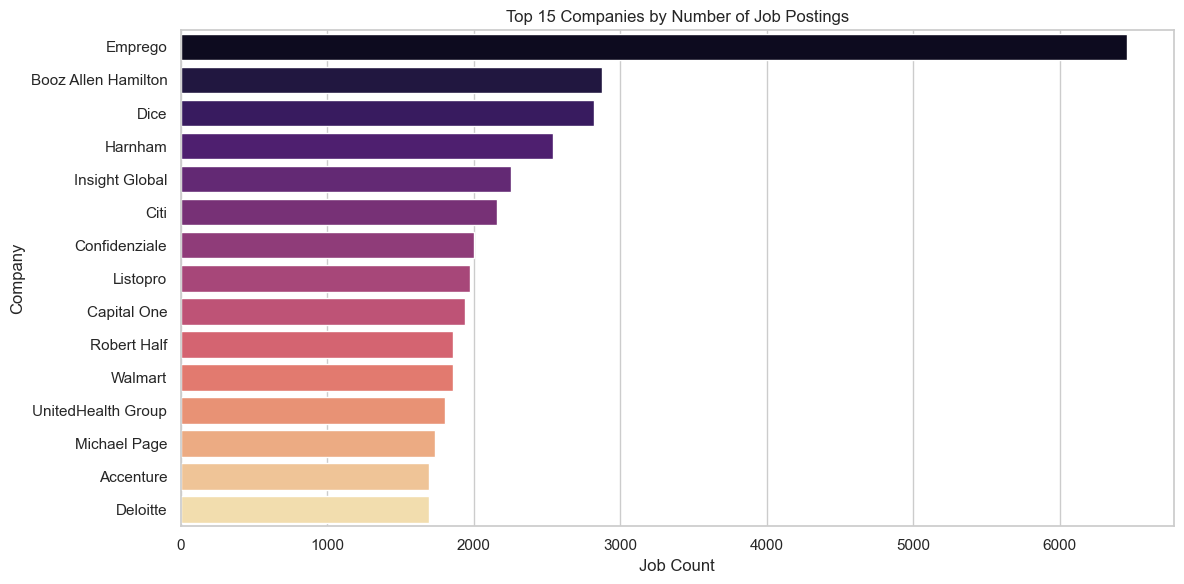

In [89]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_companies.head(15), x="job_count", y="company_name", hue="company_name", palette="magma", legend=False)
plt.title("Top 15 Companies by Number of Job Postings")
plt.xlabel("Job Count")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig("../outputs/charts/top_companies.png")
plt.show()

# 5. Top Locations

In [8]:
top_locations = jobs["job_location"].value_counts(dropna=True).reset_index()
top_locations.columns = ["job_location", "job_count"]

top_locations.head(15)

,job_location,job_count
0,Anywhere,69506
1,Singapore,23387
2,"Paris, France",12298
3,"Bengaluru, Karnataka, India",11463
4,"London, UK",10552
5,"Madrid, Spain",9785
6,"New York, NY",8153
7,India,7643
8,United States,7454
9,Hong Kong,7326


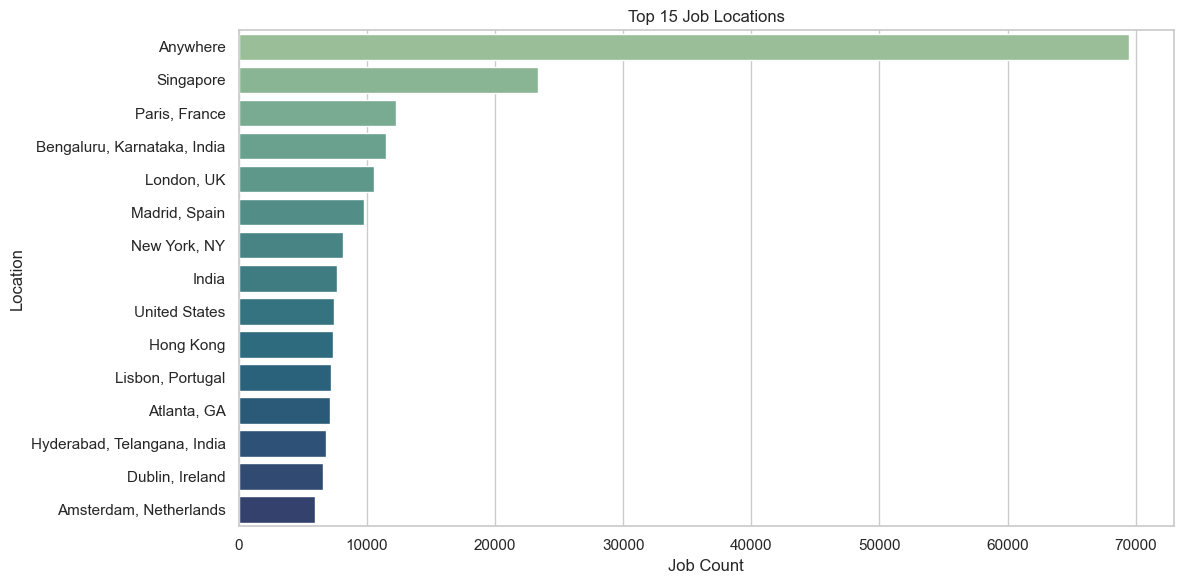

In [90]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_locations.head(15), x="job_count", y="job_location", hue="job_location", palette="crest", legend=False)
plt.title("Top 15 Job Locations")
plt.xlabel("Job Count")
plt.ylabel("Location")
plt.tight_layout()
plt.savefig("../outputs/charts/top_job_locations.png")
plt.show()

# 6. Remote vs Non-Remote

In [33]:
remote_counts = jobs["job_work_from_home"].map({True: "Remote", False: "Not Remote"}).value_counts().reset_index()
remote_counts.columns = ["work_mode", "job_count"]

remote_counts

,work_mode,job_count
0,Not Remote,715389
1,Remote,69506


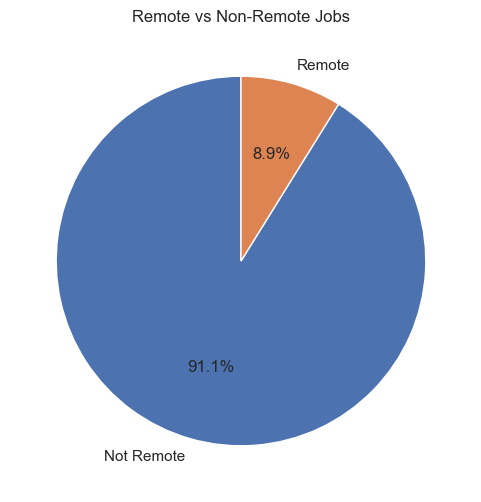

In [91]:
plt.figure(figsize=(6, 6))
plt.pie(remote_counts["job_count"], labels=remote_counts["work_mode"], autopct="%1.1f%%", startangle=90)
plt.title("Remote vs Non-Remote Jobs")
plt.savefig("../outputs/charts/remotevsNonremote.png")
plt.show()

# 7. Top Skills Overall

In [36]:
top_skills = (
    skills["skill"]
    .value_counts()
    .reset_index()
)

top_skills.columns = ["skill", "count"]

top_skills.head(20)

,skill,count
0,sql,384430
1,python,380495
2,aws,145229
3,azure,132400
4,r,130749
5,tableau,127100
6,excel,126893
7,spark,114495
8,power bi,98048
9,java,85490


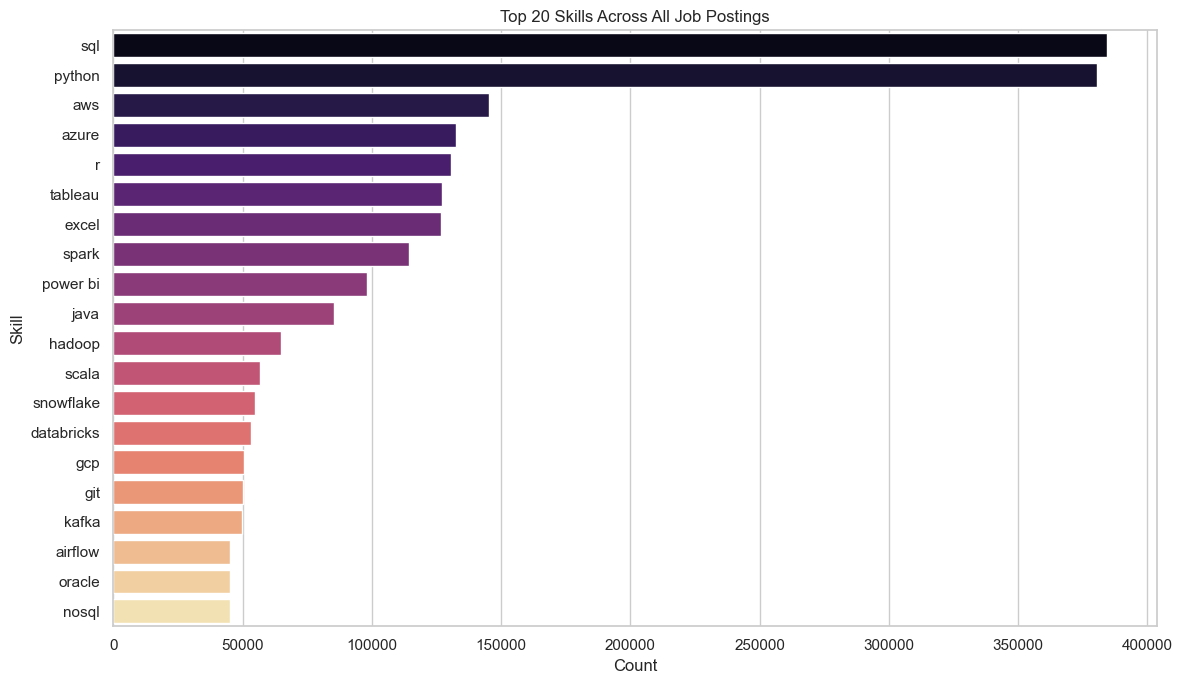

In [92]:
plt.figure(figsize=(12, 7))
sns.barplot(data=top_skills.head(20), x="count", y="skill", hue="skill", palette="magma", legend=False)
plt.title("Top 20 Skills Across All Job Postings")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("../outputs/charts/top_skills_overall.png")
plt.show()

# 8. Top Skills by Role

In [10]:
job_skill_merged = skills.merge(
    jobs[["job_key", "job_title_short"]],
    on="job_key",
    how="inner"
)

job_skill_merged.head()

,job_key,skill,job_title_short
0,5b5365941798352ebd878a5606726675,r,Data Analyst
1,5b5365941798352ebd878a5606726675,python,Data Analyst
2,5b5365941798352ebd878a5606726675,sql,Data Analyst
3,5b5365941798352ebd878a5606726675,nosql,Data Analyst
4,5b5365941798352ebd878a5606726675,power bi,Data Analyst


In [11]:
skill_role_counts = (
    job_skill_merged.groupby(["job_title_short", "skill"])
    .size()
    .reset_index(name="count")
)

skill_role_counts.head()

,job_title_short,skill,count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120


In [48]:
selected_roles = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer",
    "Business Analyst",
    "Senior Data Engineer"
]

filtered_skill_role = skill_role_counts[
    skill_role_counts["job_title_short"].isin(selected_roles)
].copy()

filtered_skill_role.head()

,job_title_short,skill,count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120


In [67]:
top_skills_by_role = (
    filtered_skill_role
    .sort_values(["job_title_short", "count"], ascending=[True, False])
    .groupby("job_title_short")
    .head(8)
    .copy()
)

top_skills_by_role.head(10)

,job_title_short,skill,count
179,Business Analyst,sql,17331
54,Business Analyst,excel,17094
192,Business Analyst,tableau,9308
138,Business Analyst,power bi,9225
145,Business Analyst,python,8081
140,Business Analyst,powerpoint,4580
148,Business Analyst,r,4025
218,Business Analyst,word,3665
625,Data Analyst,sql,92326
494,Data Analyst,excel,66790


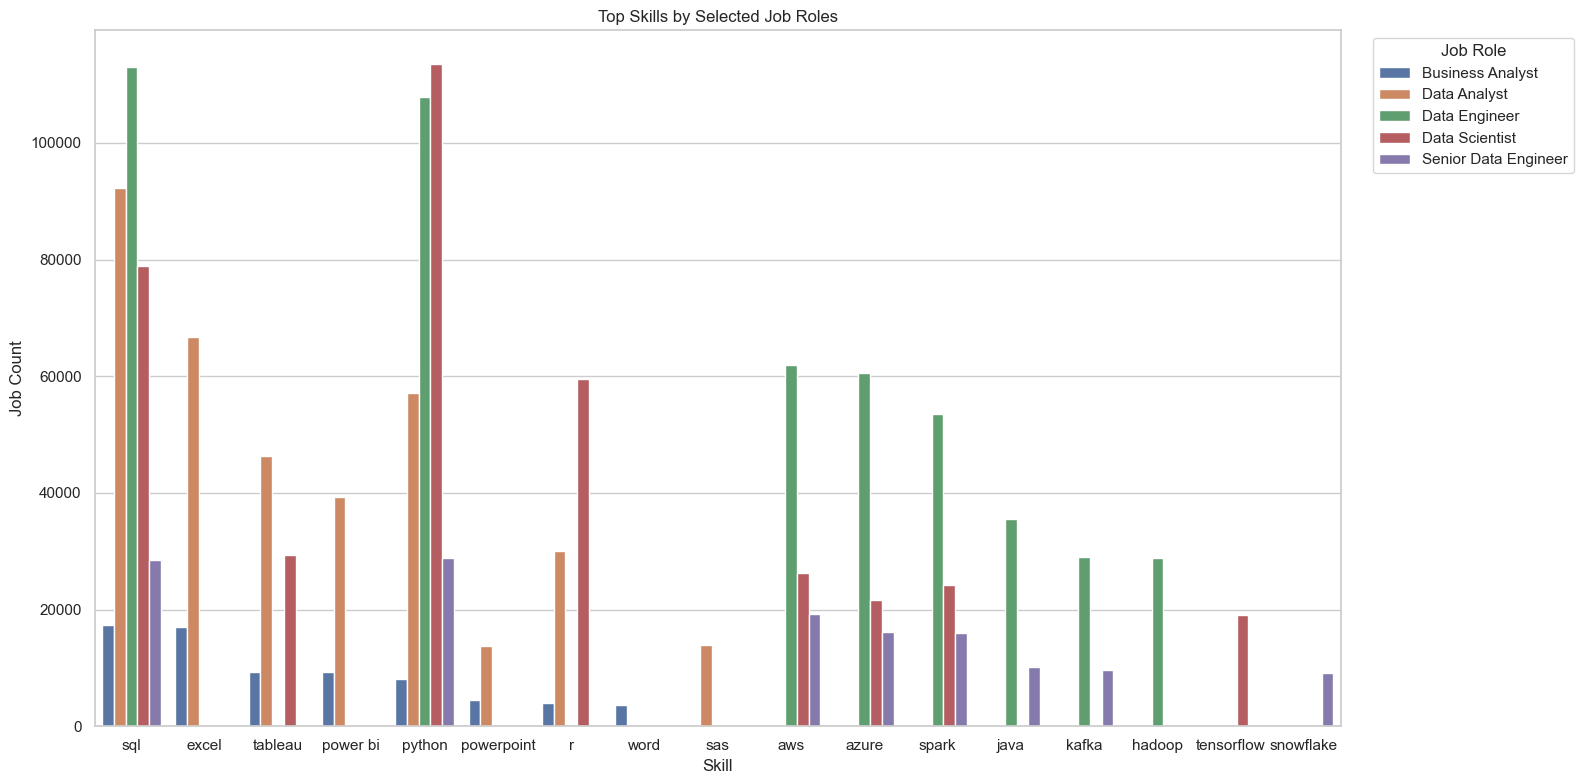

In [93]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=top_skills_by_role,
    x="skill",
    y="count",
    hue="job_title_short"
)

plt.title("Top Skills by Selected Job Roles")
plt.xlabel("Skill")
plt.ylabel("Job Count")
plt.legend(title="Job Role", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/charts/top_skills_by_role_group_map.png")
plt.show()

# 9. Jobs Over Time

In [14]:
jobs_over_time = (
    jobs.groupby(jobs["job_posted_date"].dt.date)
    .size()
    .reset_index(name="job_count")
)

jobs_over_time.columns = ["job_posted_date", "job_count"]
jobs_over_time.head()

,job_posted_date,job_count
0,2023-01-01,3587
1,2023-01-02,2771
2,2023-01-03,2560
3,2023-01-04,3936
4,2023-01-05,3291


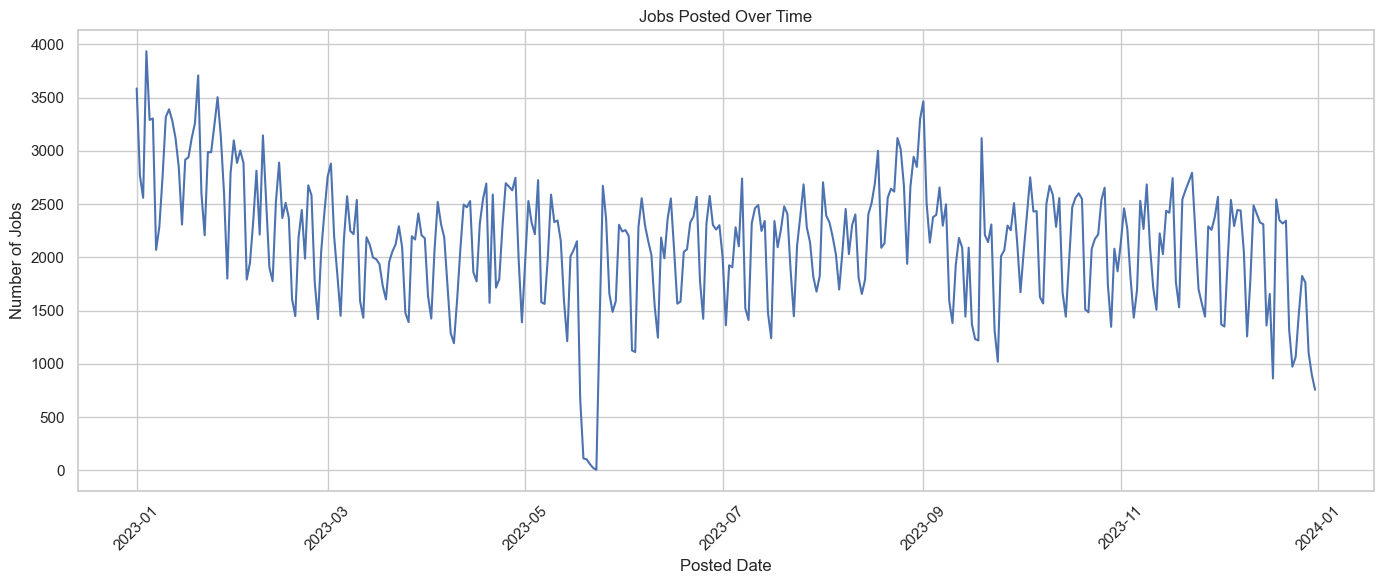

In [94]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=jobs_over_time, x="job_posted_date", y="job_count")
plt.title("Jobs Posted Over Time")
plt.xlabel("Posted Date")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/charts/jobs_over_years.png")
plt.show()

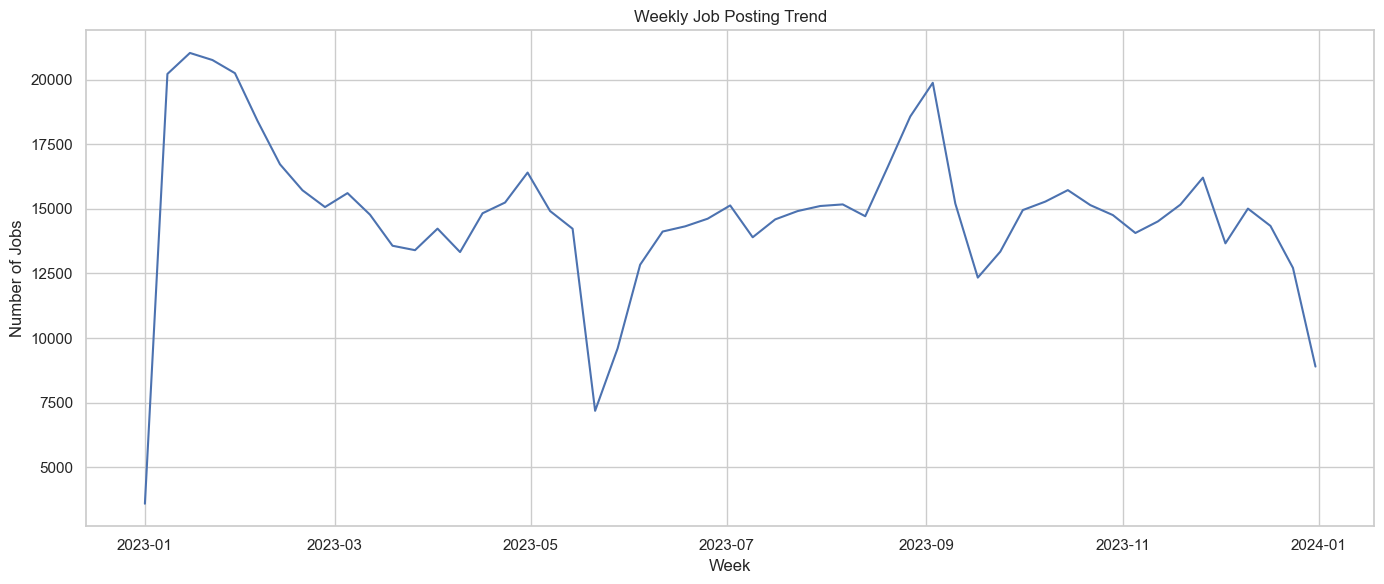

In [95]:
jobs_weekly = (
    jobs.set_index("job_posted_date")
    .resample("W")
    .size()
    .reset_index(name="job_count")
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=jobs_weekly, x="job_posted_date", y="job_count")
plt.title("Weekly Job Posting Trend")
plt.xlabel("Week")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.savefig("../outputs/charts/jobs_over_weeks.png")
plt.show()

# 10. Salary Distribution

In [38]:
salary_data = jobs["salary_year_avg"].dropna()

print("Number of jobs with annual salary:", len(salary_data))
salary_data.describe()

Number of jobs with annual salary: 21997


count     21997.000000
mean     123292.217571
std       48316.796058
min       15000.000000
25%       90000.000000
50%      115000.000000
75%      150000.000000
max      960000.000000
Name: salary_year_avg, dtype: float64

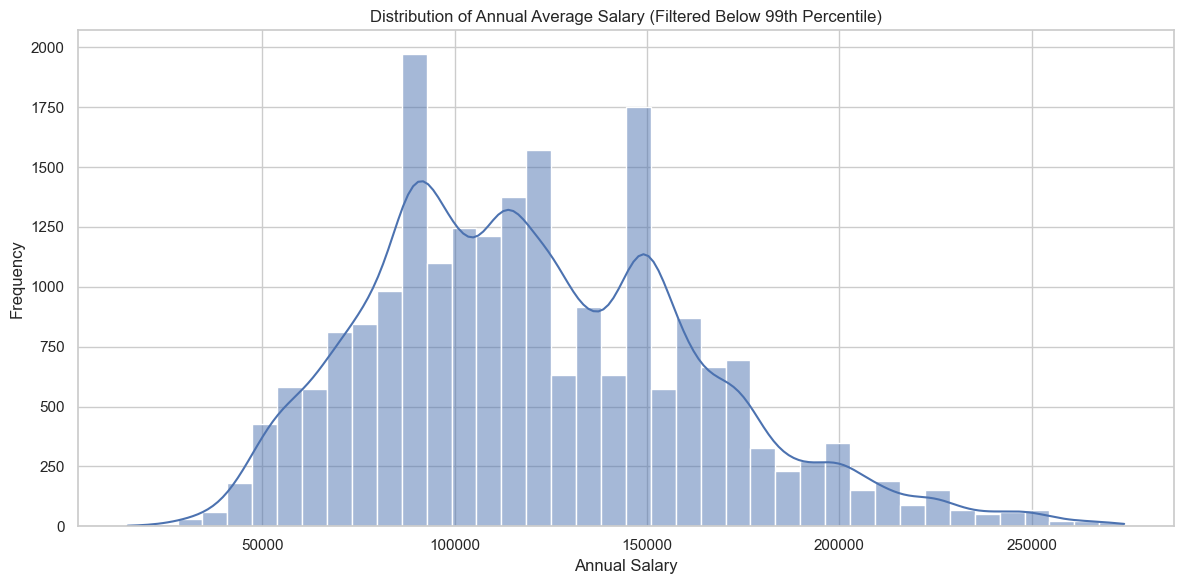

In [96]:
salary_filtered = salary_data[salary_data < salary_data.quantile(0.99)]

plt.figure(figsize=(12, 6))
sns.histplot(salary_filtered, bins=40, kde=True)
plt.title("Distribution of Annual Average Salary (Filtered Below 99th Percentile)")
plt.xlabel("Annual Salary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../outputs/charts/annual_salary_histogram.png")
plt.show()

# 11. Salary by Role

In [42]:
top_role_names = jobs["job_title_short"].value_counts().head(8).index.tolist()
top_role_names

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Business Analyst',
 'Software Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist',
 'Senior Data Analyst']

In [43]:
salary_by_role = jobs[
    jobs["job_title_short"].isin(top_role_names) &
    jobs["salary_year_avg"].notna()
][["job_title_short", "salary_year_avg"]].copy()

salary_by_role.head()

,job_title_short,salary_year_avg
28,Data Scientist,109500.0
77,Data Engineer,140000.0
92,Data Engineer,120000.0
100,Data Scientist,228222.0
109,Data Analyst,89000.0


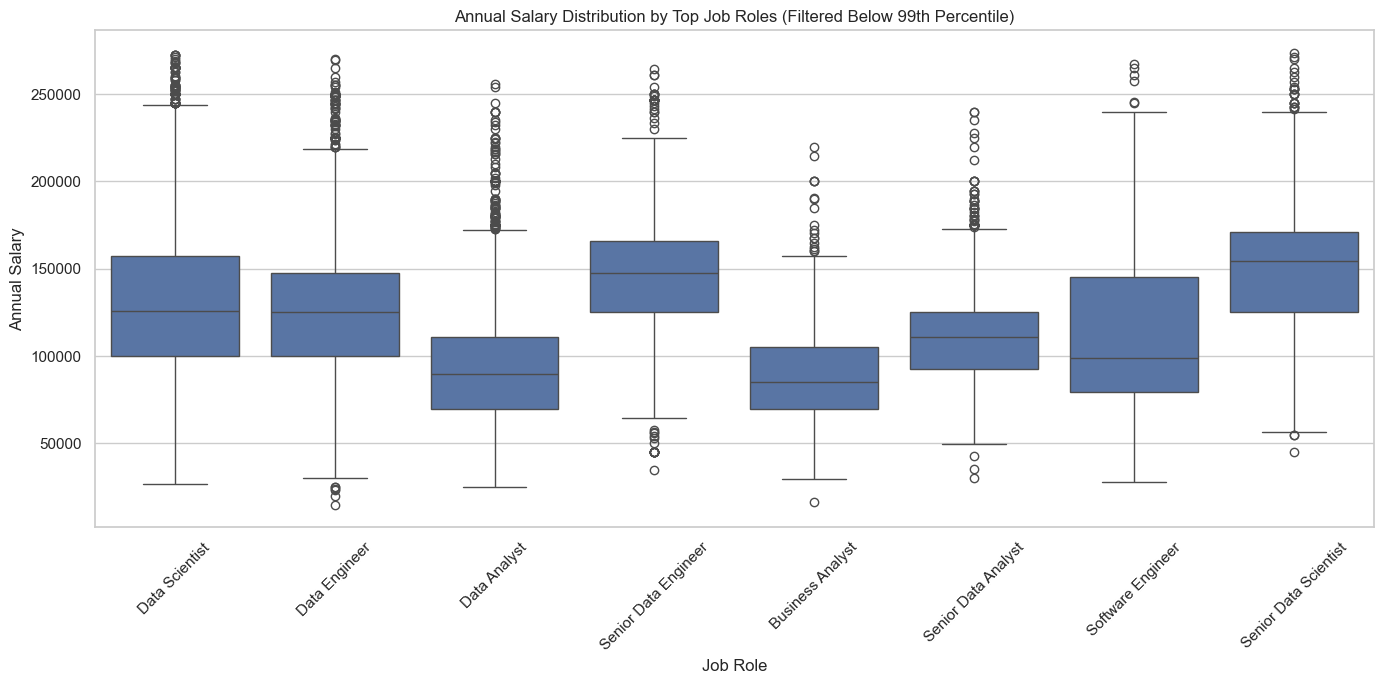

In [97]:
salary_by_role_filtered = salary_by_role[
    salary_by_role["salary_year_avg"] < salary_by_role["salary_year_avg"].quantile(0.99)
]

plt.figure(figsize=(14, 7))
sns.boxplot(data=salary_by_role_filtered, x="job_title_short", y="salary_year_avg")
plt.title("Annual Salary Distribution by Top Job Roles (Filtered Below 99th Percentile)")
plt.xlabel("Job Role")
plt.ylabel("Annual Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/charts/salary_by_job_roles.png")
plt.show()

# 12. Skill Co-occurrence

In [69]:
top_15_skills = skills["skill"].value_counts().head(15).index.tolist()
top_15_skills

['sql',
 'python',
 'aws',
 'azure',
 'r',
 'tableau',
 'excel',
 'spark',
 'power bi',
 'java',
 'hadoop',
 'scala',
 'snowflake',
 'databricks',
 'gcp']

In [70]:
skills_top = skills[skills["skill"].isin(top_15_skills)].copy()
skills_top.head()

,job_key,skill
0,5b5365941798352ebd878a5606726675,r
1,5b5365941798352ebd878a5606726675,python
2,5b5365941798352ebd878a5606726675,sql
4,5b5365941798352ebd878a5606726675,power bi
5,5b5365941798352ebd878a5606726675,tableau


In [72]:
job_skill_matrix = pd.crosstab(skills_top["job_key"], skills_top["skill"])
job_skill_matrix.head()

skill,aws,azure,databricks,excel,gcp,hadoop,java,power bi,python,r,scala,snowflake,spark,sql,tableau
job_key,,,,,,,,,,,,,,,
000012dc11b93885a8ae649ac837e842,0,0,0,0,1,1,0,0,1,0,1,0,1,1,0
0000289eda4843fc739221b56f7bd7b3,0,0,0,1,0,0,0,1,0,0,0,0,0,1,1
0000367988afe3634b6534fd8f006257,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0
000053e1f7b12235308c01dc17ef9ffe,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
000055757df5796b9d6e504446236470,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1


In [73]:
co_occurrence = job_skill_matrix.T.dot(job_skill_matrix)
co_occurrence.head()

skill,aws,azure,databricks,excel,gcp,hadoop,java,power bi,python,r,scala,snowflake,spark,sql,tableau
skill,,,,,,,,,,,,,,,
aws,145229,59002,18646,8016,33344,25815,33559,13123,109949,23057,25845,27738,49578,91265,24552
azure,59002,132400,37204,8453,27831,20728,24639,27161,88948,21591,21746,20305,41530,90283,19444
databricks,18646,37204,53131,3095,6063,7589,8466,10217,40081,8482,10963,10992,23880,39069,8270
excel,8016,8453,3095,126893,2454,4358,5144,31033,42671,23915,2574,4329,5722,66849,35809
gcp,33344,27831,6063,2454,50669,9760,12392,4470,38708,7664,9690,6776,17994,32753,8011


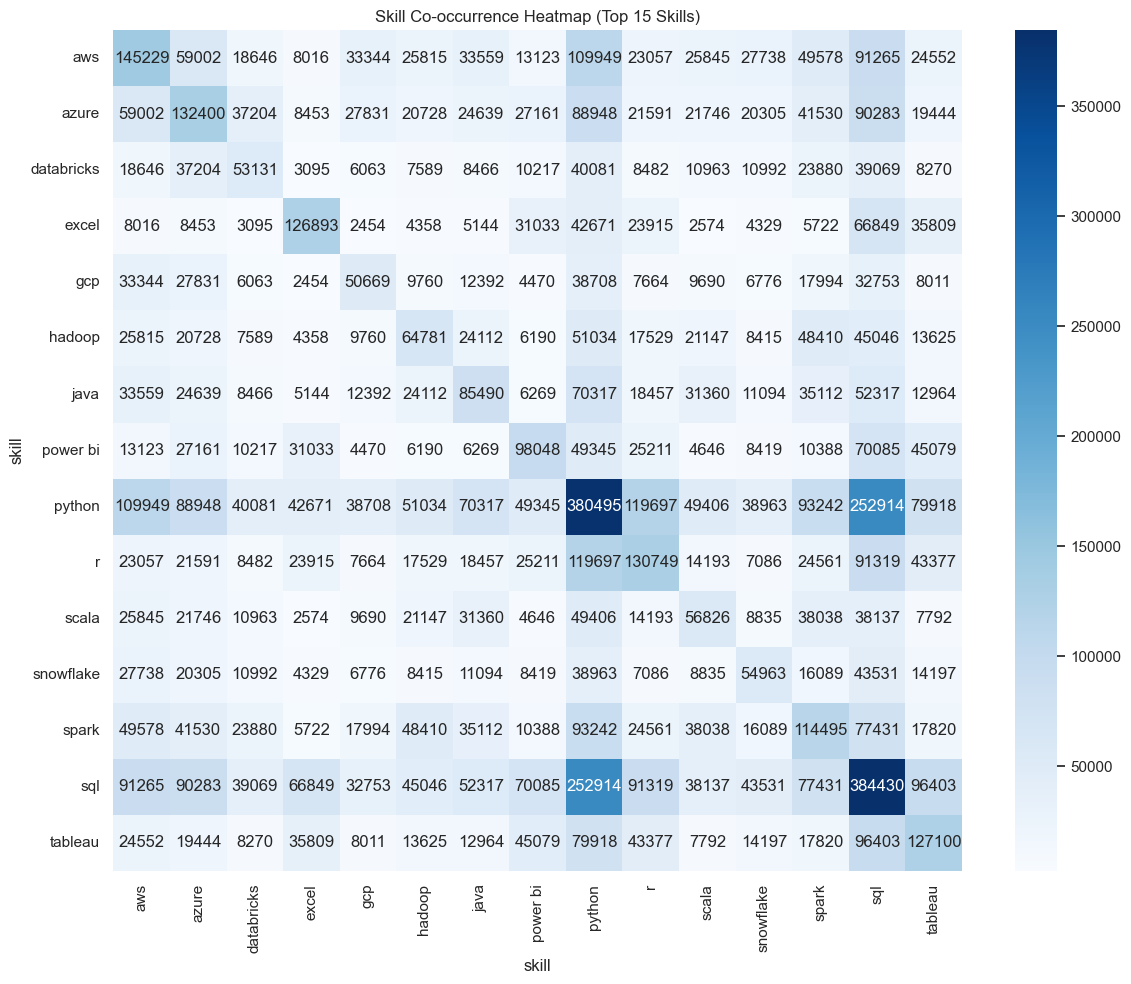

In [98]:
plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues")
plt.title("Skill Co-occurrence Heatmap (Top 15 Skills)")
plt.tight_layout()
plt.savefig("../outputs/charts/skill_co_occurrence.png")
plt.show()

In [75]:
top_roles_for_heatmap = jobs["job_title_short"].value_counts().head(6).index.tolist()
top_roles_for_heatmap

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Business Analyst',
 'Software Engineer',
 'Senior Data Engineer']

In [76]:
top_skills_for_heatmap = skills["skill"].value_counts().head(15).index.tolist()
top_skills_for_heatmap

['sql',
 'python',
 'aws',
 'azure',
 'r',
 'tableau',
 'excel',
 'spark',
 'power bi',
 'java',
 'hadoop',
 'scala',
 'snowflake',
 'databricks',
 'gcp']

In [77]:
job_skill_role = skills.merge(
    jobs[["job_key", "job_title_short"]],
    on="job_key",
    how="inner"
)

job_skill_role = job_skill_role[
    job_skill_role["job_title_short"].isin(top_roles_for_heatmap) &
    job_skill_role["skill"].isin(top_skills_for_heatmap)
]

In [78]:
role_skill_matrix = pd.crosstab(
    job_skill_role["job_title_short"],
    job_skill_role["skill"]
)

role_skill_matrix

skill,aws,azure,databricks,excel,gcp,hadoop,java,power bi,python,r,scala,snowflake,spark,sql,tableau
job_title_short,,,,,,,,,,,,,,,
Business Analyst,1820,2533,528,17094,579,626,1121,9225,8081,4025,234,1186,743,17331,9308
Data Analyst,9037,10904,3151,66790,3384,4179,5232,39326,57128,29956,1854,6170,5024,92326,46402
Data Engineer,61980,60615,27446,8500,22192,28790,35509,18816,107879,12643,28679,26591,53594,112984,18754
Data Scientist,26233,21643,8544,17531,8708,15521,16228,15710,113598,59500,10379,5755,24261,78901,29419
Senior Data Engineer,19311,16160,7802,1467,6279,7821,10119,4144,28854,2503,8612,9096,16034,28570,4690
Software Engineer,10427,7092,1127,2613,3283,1806,9835,1408,15228,1245,2289,1529,3499,12315,1793


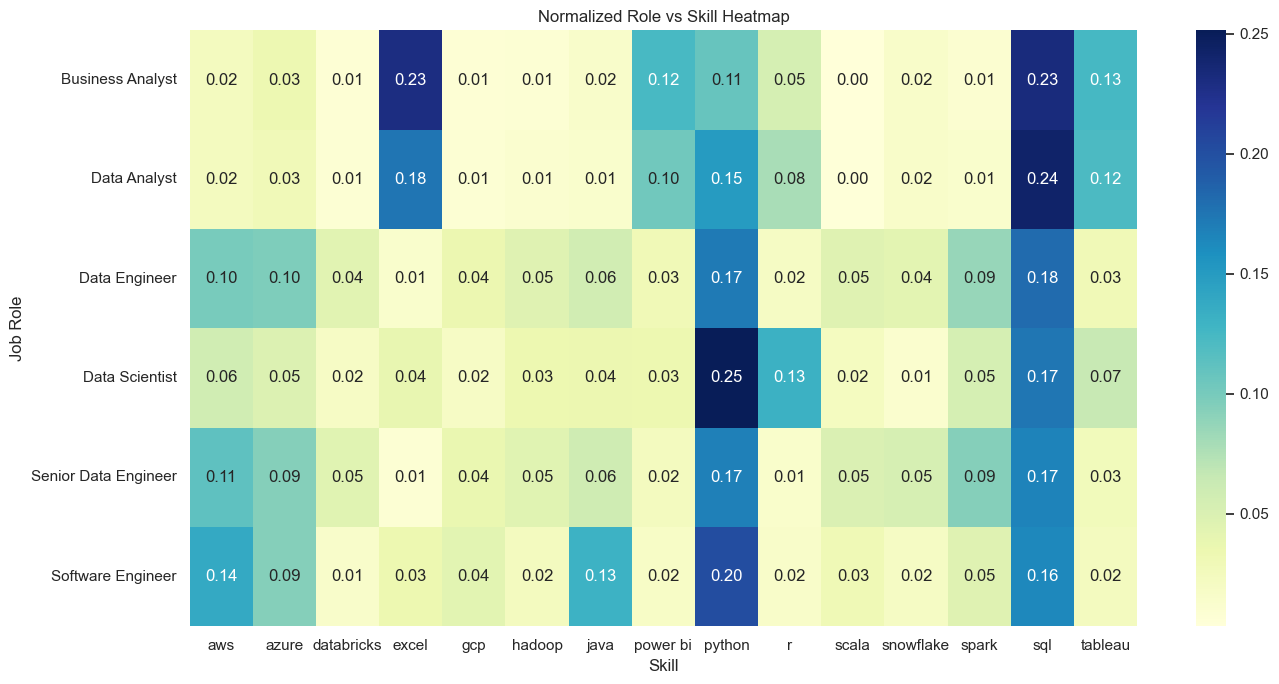

In [99]:
role_skill_matrix_norm = role_skill_matrix.div(role_skill_matrix.sum(axis=1), axis=0)

plt.figure(figsize=(14, 7))
sns.heatmap(role_skill_matrix_norm, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Normalized Role vs Skill Heatmap")
plt.xlabel("Skill")
plt.ylabel("Job Role")
plt.tight_layout()
plt.savefig("../outputs/charts/top_skills_by_role_heatmap.png")
plt.show()

## Key EDA Insights

1. Data Analyst, Data Engineer, and Data Scientist are the most common roles in the dataset.
2. Job postings are concentrated among a limited set of employers and global locations, with “Anywhere” appearing prominently.
3. The dataset is heavily non-remote, with remote postings making up a small minority.
4. SQL and Python are the most demanded skills overall, followed by cloud, BI, and distributed-processing tools.
5. Skill demand varies by role: analyst roles emphasize BI/reporting tools, while engineering roles emphasize cloud and big data tools.
6. Skill co-occurrence shows that employers hire for combinations of tools rather than isolated skills.
7. Weekly job posting volume is relatively stable with noticeable peaks and dips, supporting time-based analysis and forecasting.
8. Salary distribution is right-skewed, with most salaries concentrated in a moderate band and a smaller number of high-end outliers.
9. Senior technical roles tend to have higher median salaries than analyst-focused roles.